In [25]:
from IPython.core.magic import register_cell_magic
from IPython.display import display
import threading, time, tracemalloc

@register_cell_magic
def monitor(_, cell):
    tracemalloc.start()
    start = time.time()
    stop_event = threading.Event()
    handle = display("starting...", display_id=True)

    def report_loop():
        while not stop_event.wait(0.5):  # poll every 0.5s
            current, peak = tracemalloc.get_traced_memory()
            elapsed = time.time() - start
            handle.update(f"[t={elapsed:6.2f}s] current={current/1e6:.1f}MB peak={peak/1e6:.1f}MB")

    t = threading.Thread(target=report_loop, daemon=True)
    t.start()
    try:
        get_ipython().run_cell(cell)
    finally:
        stop_event.set()
        t.join()

    elapsed = time.time() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"\n--- Monitoring report ---")
    print(f"[memory] current: {current/1e6:.1f} MB, peak: {peak/1e6:.1f} MB")
    print(f"[speed] time elapsed: {elapsed:.3f}s")

In [26]:
from pathlib import Path
import dask.array as da
import numpy as np

from pathlib import Path
in_path = Path("./rechunked.zarr")

streamed_imaging = da.from_zarr(in_path)
average = da.from_zarr(Path("./average.zarr"))
print(streamed_imaging.chunksize)


def naive_nbytes(array):
    nbytes_in_g = int(np.prod(array.shape)) * np.dtype(array.dtype).itemsize / 1024**3
    print(f"Size on disk: {(nbytes_in_g):.2f} GiB")
    return nbytes_in_g

nbytes = naive_nbytes(streamed_imaging)


(20, 50, 50)
Size on disk: 0.29 GiB


'starting...'

dask.array<mul, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>


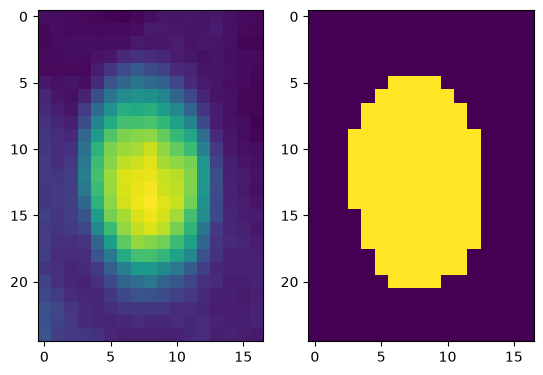


--- Monitoring report ---
[memory] current: 1.2 MB, peak: 8.9 MB
[speed] time elapsed: 0.260s


In [27]:
%%monitor
import matplotlib.pyplot as plt

single_neuron_slice = (slice(115,140), slice(78,95))
threshold = 0.30*average.max()
print(threshold)
neuron_mask = average[single_neuron_slice]>threshold
plt.subplot(1, 2, 1)
plt.imshow(average[single_neuron_slice])
plt.subplot(1, 2, 2)
plt.imshow(neuron_mask)
plt.show()


In [28]:

%%monitor
single_neuron = streamed_imaging[:,*single_neuron_slice]


'starting...'


--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.0 MB
[speed] time elapsed: 0.004s


In [29]:
%%monitor
import numpy as np

print(single_neuron.shape)
print(neuron_mask.shape)


masked = da.where(neuron_mask, single_neuron, np.nan)
neuron_intensity_over_time =  da.nanmean(masked, axis=(1, 2))
print(neuron_intensity_over_time.shape)


'starting...'

(380, 25, 17)
(25, 17)
(380,)

--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.1 MB
[speed] time elapsed: 0.007s


'starting...'

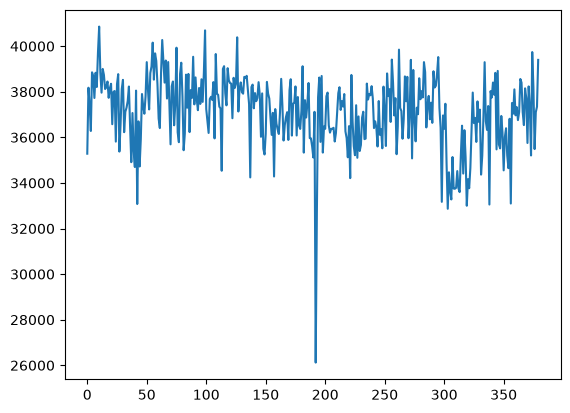


--- Monitoring report ---
[memory] current: 1.1 MB, peak: 12.1 MB
[speed] time elapsed: 0.334s


In [30]:
%%monitor

plt.figure()
plt.plot(neuron_intensity_over_time)
plt.show()
normalised_neuron_intensity_over_time = None
import numpy as np
import dask.array as da

def masked_spatial_mean(chunk: np.ndarray, threshold) -> np.ndarray:
        mask = chunk > threshold
        masked = np.where(mask, chunk, np.nan)
        return np.nanmean(masked, axis=(1, 2))


In [31]:
%%monitor

neuron_intensity_over_time_1 = streamed_imaging[:, *single_neuron_slice].map_blocks(masked_spatial_mean, threshold=threshold, drop_axis=(1,2), dtype=np.float32).compute()


'starting...'


--- Monitoring report ---
[memory] current: 0.1 MB, peak: 12.9 MB
[speed] time elapsed: 0.066s


'starting...'

(380, 25, 17)
(380,)


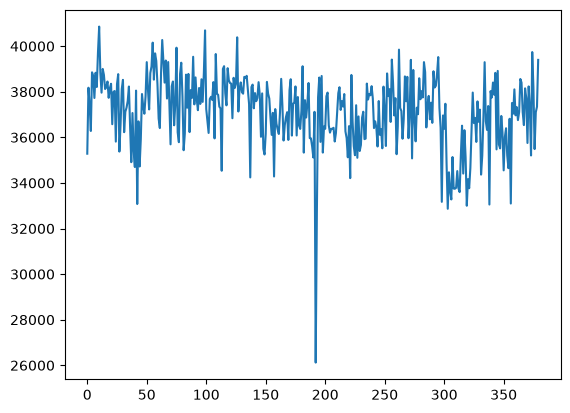


--- Monitoring report ---
[memory] current: 1.0 MB, peak: 12.1 MB
[speed] time elapsed: 0.280s


In [32]:
%%monitor

single_neuron_all_time = streamed_imaging[:,*single_neuron_slice]
print(single_neuron_all_time.shape)
masked_time = da.where(neuron_mask, single_neuron_all_time, np.nan)
neuron_intensity_over_time_2 =  da.nanmean(masked_time, axis=(1, 2)).compute()
print(neuron_intensity_over_time_2.shape)
plt.figure()
plt.plot(neuron_intensity_over_time_2)
plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter1d, maximum_filter1d, minimum_filter1d

F0 = gaussian_filter1d(F, sigma=5, axis=0)
F0 = minimum_filter1d(F0, size=win, axis=0)
F0 = maximum_filter1d(F0, size=win, axis=0)

NameError: name 'F' is not defined